# 01 - exploracion de datos

## Proyecto
**Clasificación de razas de perros y gatos con CNN y Transfer Learning**  
Dataset: **Oxford-IIIT Pet Dataset**

## Objetivo de este notebook
En este notebook se realiza una exploración inicial del conjunto de datos para:

1. cargar el dataset de forma reproducible en Google Colab,
2. inspeccionar su estructura,
3. visualizar imágenes y etiquetas,
4. analizar la distribución de clases,
5. revisar tamaños de imagen y algunas características visuales,
6. extraer observaciones que sirvan para el diseño del preprocesado y de los modelos.

> Este notebook no entrena modelos. Su propósito es comprender el problema y dejar documentadas las características principales de los datos.

## 1. Importación de librerías

En esta sección importamos las librerías necesarias.

- **tensorflow**: framework principal para construir el pipeline de datos y, más adelante, los modelos.
- **tensorflow_datasets (tfds)**: permite descargar y cargar el dataset `oxford_iiit_pet` de manera reproducible.
- **matplotlib** y **seaborn**: se usan para visualización.
- **numpy** y **pandas**: apoyan el análisis numérico y tabular.
- **collections.Counter**: facilita el conteo de etiquetas.

In [1]:
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_context("notebook")
print("TensorFlow version:", tf.__version__)
print("TensorFlow Datasets version:", tfds.__version__)

TensorFlow version: 2.20.0
TensorFlow Datasets version: 4.9.10


## 2. Carga del dataset

Usamos `tfds.load` para descargar y cargar el dataset directamente desde **TensorFlow Datasets**.  
Esto es importante porque hace que el notebook sea más fácil de reproducir en Google Colab, sin depender de rutas locales.

### Parámetros clave
- **name**: nombre del dataset.
- **split**: partición que queremos cargar.
- **with_info=True**: devuelve también un objeto con metadatos del dataset.
- **as_supervised=False**: mantiene el formato tipo diccionario con todas las características disponibles.

In [2]:
dataset_name = "oxford_iiit_pet"

(train_ds, test_ds), info = tfds.load(
    dataset_name,
    split=["train", "test"],
    with_info=True,
    as_supervised=False
)

print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/root/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
       

## 3. Inspección general del dataset

Aquí vamos a revisar:
- nombre del dataset,
- descripción general,
- número de ejemplos por partición,
- tipo de características disponibles,
- clases objetivo.

Este análisis es importante porque nos dice exactamente qué información viene en cada ejemplo.

In [3]:
print("Nombre:", info.full_name)
print("\nDescripción:")
print(info.description[:1000], "...")
print("\nSplits disponibles:")
for split_name, split_info in info.splits.items():
    print(f"- {split_name}: {split_info.num_examples} ejemplos")

print("\nCaracterísticas:")
for feature_name, feature_obj in info.features.items():
    print(f"- {feature_name}: {feature_obj}")

Nombre: oxford_iiit_pet/4.0.0

Descripción:
The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
images for each class. The images have large variations in scale, pose and
lighting. All images have an associated ground truth annotation of breed and
species. Additionally, head bounding boxes are provided for the training split,
allowing using this dataset for simple object detection tasks. In the test
split, the bounding boxes are empty. ...

Splits disponibles:
- train: 3680 ejemplos
- test: 3669 ejemplos

Características:
- image: Image(shape=(None, None, 3), dtype=uint8)
- label: ClassLabel(shape=(), dtype=int64, num_classes=37)
- species: ClassLabel(shape=(), dtype=int64, num_classes=2)
- file_name: Text(shape=(), dtype=string)
- segmentation_mask: Image(shape=(None, None, 1), dtype=uint8)
- head_bbox: BBoxFeature(shape=(4,), dtype=float32)


## 4. Revisión de las etiquetas de clase

La tarea principal del proyecto será **clasificación multiclase de raza**.  
Por eso necesitamos revisar:

- cuántas clases hay,
- cómo se llaman,
- qué formato tiene la etiqueta.

In [4]:
label_feature = info.features["label"]
class_names = label_feature.names
num_classes = label_feature.num_classes

print("Número de clases:", num_classes)
print("\nPrimeras 10 clases:")
for i, class_name in enumerate(class_names[:10]):
    print(f"{i}: {class_name}")

Número de clases: 37

Primeras 10 clases:
0: Abyssinian
1: american_bulldog
2: american_pit_bull_terrier
3: basset_hound
4: beagle
5: Bengal
6: Birman
7: Bombay
8: boxer
9: British_Shorthair


## 5. Estructura de un ejemplo del dataset

Vamos a inspeccionar un solo ejemplo para entender qué campos contiene.

### Campos esperados
- **image**: imagen RGB de la mascota,
- **label**: clase de raza,
- **species**: especie (gato o perro),
- **segmentation_mask**: máscara de segmentación,
- **file_name**: nombre del archivo.

Aunque en este proyecto nos centraremos en clasificación, es útil notar que el dataset también tiene información para otras tareas de visión por computador.

In [5]:
sample = next(iter(train_ds))

print("Claves del ejemplo:", sample.keys())
print("Shape de la imagen:", sample["image"].shape)
print("Tipo de dato de la imagen:", sample["image"].dtype)
print("Label:", int(sample["label"].numpy()))
print("Nombre de la clase:", class_names[int(sample["label"].numpy())])
print("Species:", int(sample["species"].numpy()))
print("Shape de la máscara:", sample["segmentation_mask"].shape)
print("Nombre del archivo:", sample["file_name"].numpy().decode("utf-8"))

Claves del ejemplo: dict_keys(['file_name', 'head_bbox', 'image', 'label', 'segmentation_mask', 'species'])
Shape de la imagen: (500, 500, 3)
Tipo de dato de la imagen: <dtype: 'uint8'>
Label: 33
Nombre de la clase: Sphynx
Species: 0
Shape de la máscara: (500, 500, 1)
Nombre del archivo: Sphynx_158.jpg


## 6. Visualización de ejemplos aleatorios

En esta sección vamos a observar varias imágenes del conjunto de entrenamiento.  
Esto nos ayuda a identificar variaciones como:

- fondo,
- pose,
- iluminación,
- escala,
- orientación,
- similitud visual entre razas.

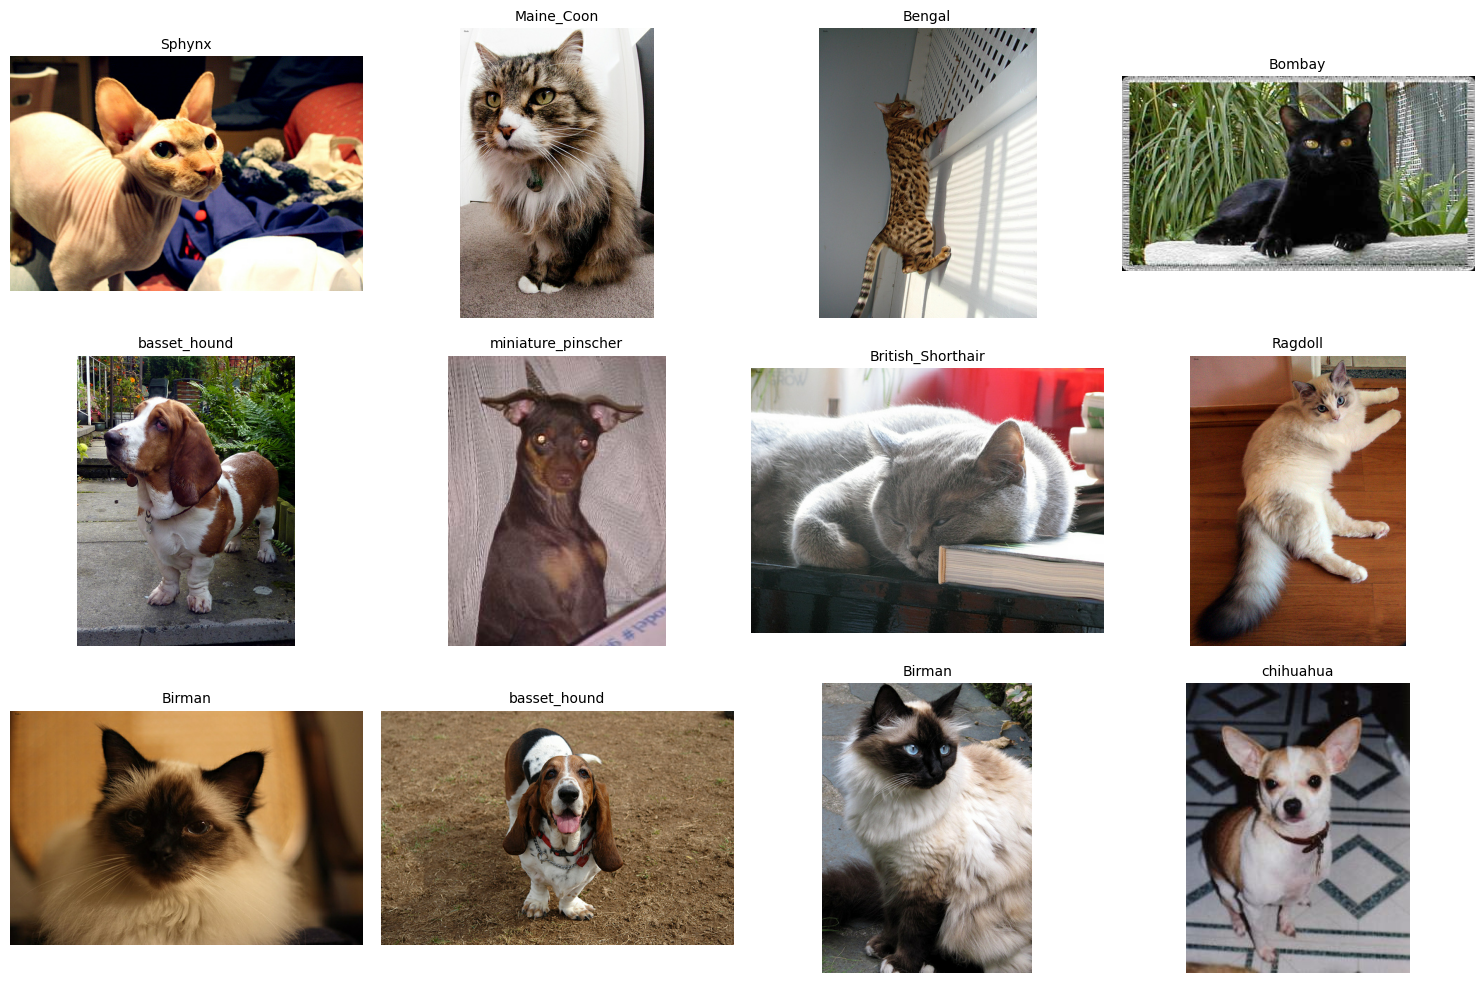

In [6]:
def show_random_samples(dataset, class_names, n=12, figsize=(15, 10)):
    samples = list(dataset.shuffle(1000, seed=SEED).take(n))
    cols = 4
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=figsize)
    for i, example in enumerate(samples, 1):
        image = example["image"].numpy()
        label = int(example["label"].numpy())
        plt.subplot(rows, cols, i)
        plt.imshow(image)
        plt.title(class_names[label], fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_random_samples(train_ds, class_names, n=12)

## 7. Visualización de una imagen junto con su máscara de segmentación

Aunque el objetivo principal del proyecto es clasificación, esta visualización ayuda a entender mejor el dataset.  
La máscara permite ver qué región corresponde a la mascota y qué región pertenece al fondo.

Esto es útil porque muestra que el fondo podría introducir ruido visual en la tarea de clasificación.

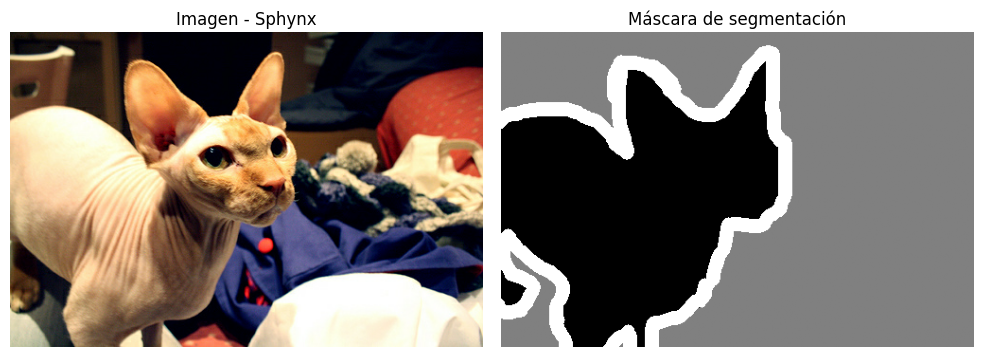

In [7]:
example = next(iter(train_ds.shuffle(1000, seed=SEED)))
image = example["image"].numpy()
mask = example["segmentation_mask"].numpy().squeeze()
label = int(example["label"].numpy())

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Imagen - {class_names[label]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Máscara de segmentación")
plt.axis("off")

plt.tight_layout()
plt.show()

## 8. Distribución de clases en entrenamiento

Aquí contaremos cuántos ejemplos hay por clase en el conjunto de entrenamiento.  
Esto es importante para verificar si el problema está balanceado o no.

Un dataset relativamente balanceado suele facilitar el entrenamiento y la interpretación de métricas como accuracy.

In [8]:
train_labels = [int(example["label"]) for example in tfds.as_numpy(train_ds)]
train_counts = Counter(train_labels)

class_distribution_df = pd.DataFrame({
    "class_id": list(train_counts.keys()),
    "class_name": [class_names[i] for i in train_counts.keys()],
    "count": list(train_counts.values())
}).sort_values("count", ascending=False)

class_distribution_df.head()

,class_id,class_name,count
0,33,Sphynx,100
2,9,British_Shorthair,100
4,2,american_pit_bull_terrier,100
7,5,Bengal,100
6,36,yorkshire_terrier,100


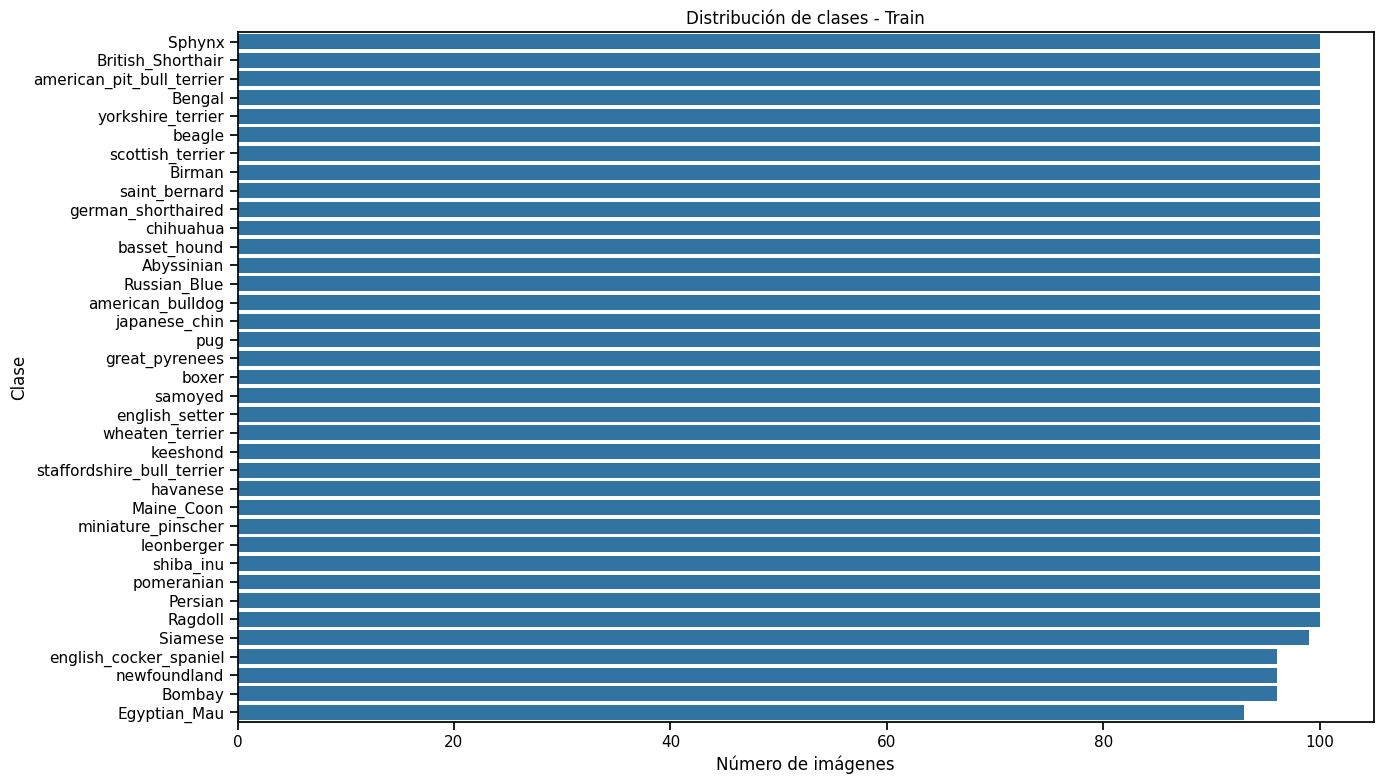

Número mínimo de imágenes por clase: 93
Número máximo de imágenes por clase: 100
Promedio de imágenes por clase: 99.46


In [9]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=class_distribution_df,
    x="count",
    y="class_name"
)
plt.title("Distribución de clases - Train")
plt.xlabel("Número de imágenes")
plt.ylabel("Clase")
plt.tight_layout()
plt.show()

print("Número mínimo de imágenes por clase:", class_distribution_df["count"].min())
print("Número máximo de imágenes por clase:", class_distribution_df["count"].max())
print("Promedio de imágenes por clase:", round(class_distribution_df["count"].mean(), 2))

## 9. Distribución por especie

El dataset también incluye la variable **species**, que indica si la mascota es perro o gato.  
Aunque nuestro objetivo final es clasificar razas, esta variable nos permite revisar la composición general del conjunto.

In [10]:
species_values = [int(example["species"]) for example in tfds.as_numpy(train_ds)]
species_counts = Counter(species_values)

species_df = pd.DataFrame({
    "species_id": list(species_counts.keys()),
    "count": list(species_counts.values())
}).sort_values("species_id")

species_df

,species_id,count
0,0,1188
1,1,2492


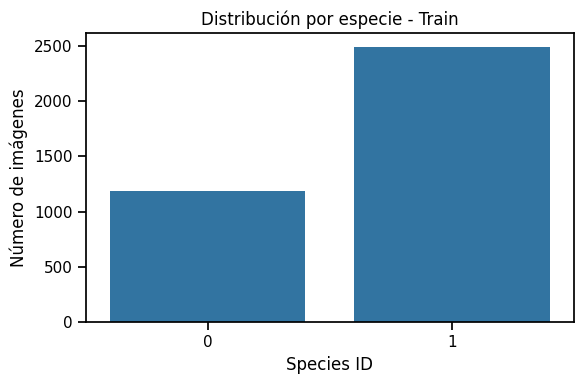

In [11]:
plt.figure(figsize=(6, 4))
sns.barplot(data=species_df, x="species_id", y="count")
plt.title("Distribución por especie - Train")
plt.xlabel("Species ID")
plt.ylabel("Número de imágenes")
plt.tight_layout()
plt.show()

## 10. Tamaños de imagen

Las imágenes del dataset no necesariamente tienen todas el mismo tamaño.  
Esto es clave, porque los modelos CNN suelen requerir una dimensión fija de entrada.

En esta sección analizaremos:
- altura,
- anchura,
- canales,
- rango aproximado de tamaños.

In [12]:
image_shapes = []

for example in tfds.as_numpy(train_ds.take(500)):
    shape = example["image"].shape
    image_shapes.append(shape)

shape_df = pd.DataFrame(image_shapes, columns=["height", "width", "channels"])
shape_df.head()

,height,width,channels
0,500,500,3
1,313,500,3
2,500,333,3
3,375,500,3
4,500,333,3


            height        width  channels
count   500.000000   500.000000     500.0
mean    385.908000   430.650000       3.0
std     118.338394   136.894996       0.0
min     143.000000   114.000000       3.0
25%     333.000000   334.000000       3.0
50%     375.000000   500.000000       3.0
75%     500.000000   500.000000       3.0
max    1920.000000  2560.000000       3.0


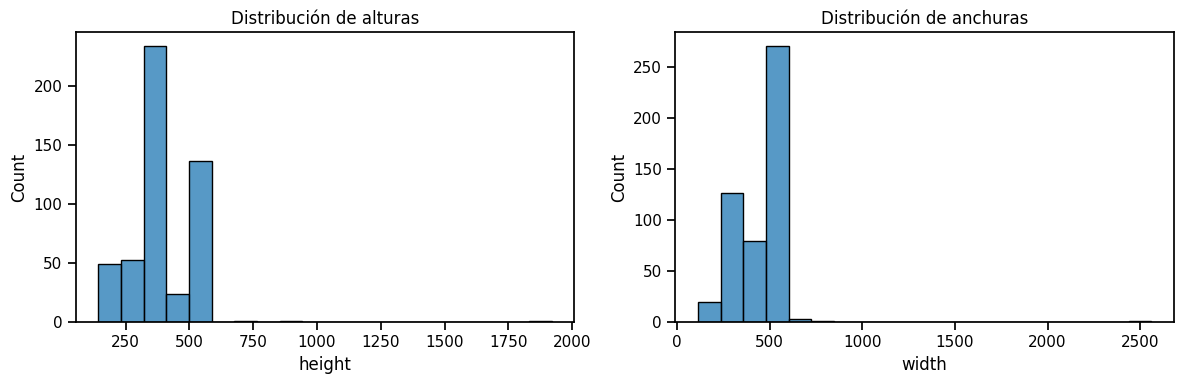

In [13]:
print(shape_df.describe())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(shape_df["height"], bins=20)
plt.title("Distribución de alturas")

plt.subplot(1, 2, 2)
sns.histplot(shape_df["width"], bins=20)
plt.title("Distribución de anchuras")

plt.tight_layout()
plt.show()

## 11. Algunas imágenes por clase

Ahora visualizaremos una muestra pequeña de distintas clases para observar mejor la variabilidad intraclase e interclase.

- **Variabilidad intraclase**: diferencias entre imágenes de la misma raza.
- **Variabilidad interclase**: diferencias entre razas distintas.

Esto ayuda a entender por qué el problema no es trivial.

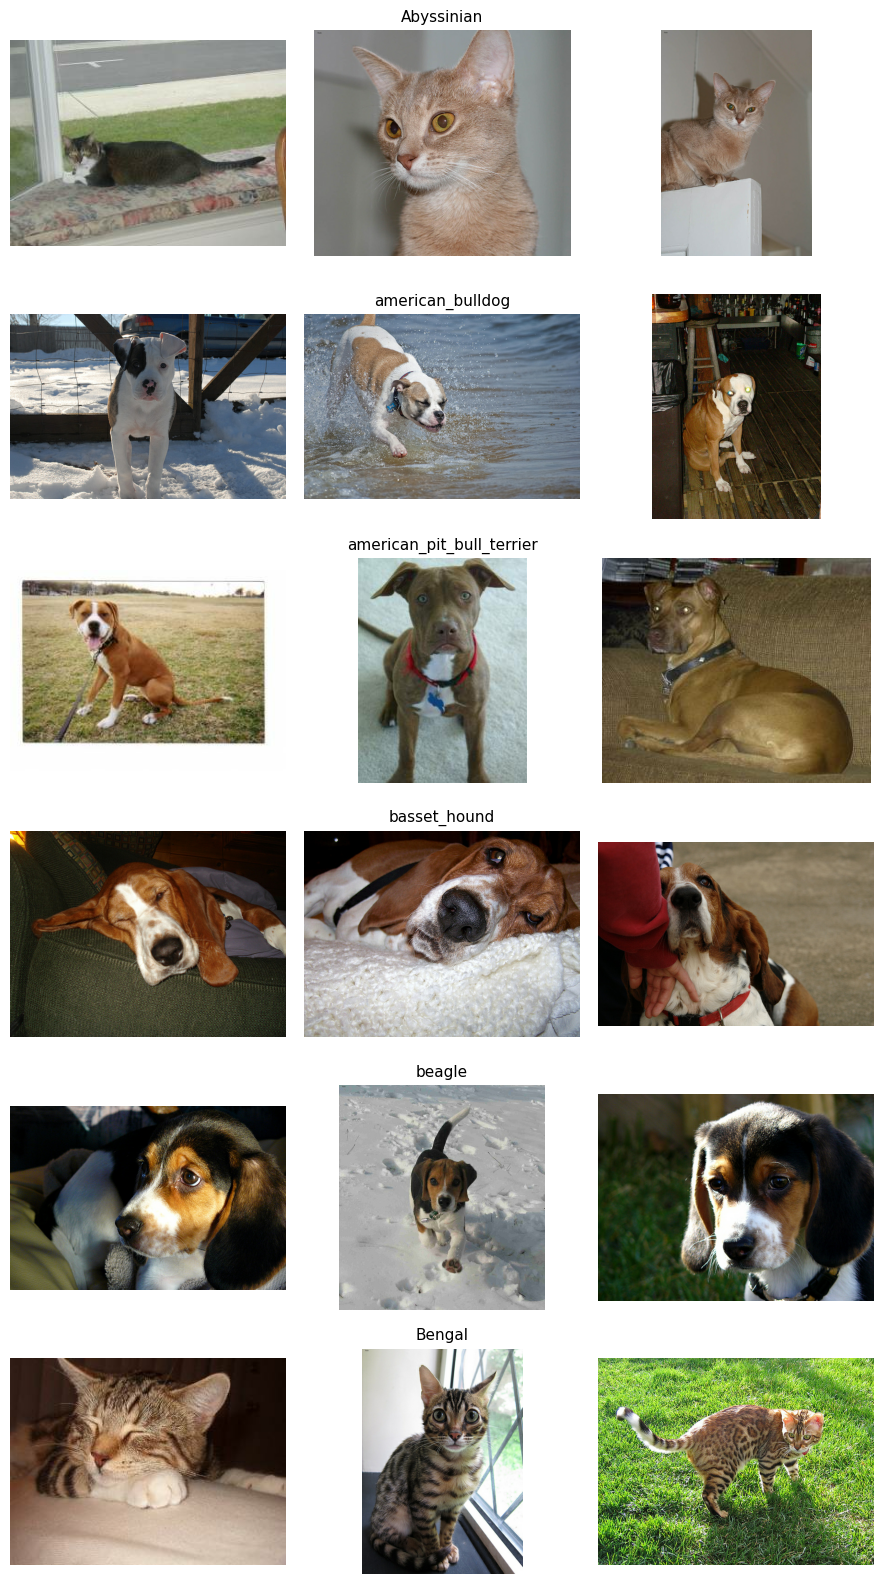

In [14]:
def collect_examples_by_class(dataset, num_classes_to_show=6, samples_per_class=3):
    selected_class_ids = list(range(num_classes_to_show))
    collected = {class_id: [] for class_id in selected_class_ids}

    for example in dataset:
        label = int(example["label"].numpy())
        if label in collected and len(collected[label]) < samples_per_class:
            collected[label].append(example["image"].numpy())

        if all(len(images) >= samples_per_class for images in collected.values()):
            break

    return collected

examples_by_class = collect_examples_by_class(train_ds, num_classes_to_show=6, samples_per_class=3)

fig, axes = plt.subplots(6, 3, figsize=(9, 16))
for row_idx, class_id in enumerate(examples_by_class.keys()):
    for col_idx in range(3):
        axes[row_idx, col_idx].imshow(examples_by_class[class_id][col_idx])
        axes[row_idx, col_idx].axis("off")
        if col_idx == 1:
            axes[row_idx, col_idx].set_title(class_names[class_id], fontsize=11)

plt.tight_layout()
plt.show()

## 12. Preparación de un resumen tabular del dataset

Este pequeño resumen es útil para luego reutilizarlo en el informe del proyecto.

In [15]:
summary_df = pd.DataFrame({
    "aspecto": [
        "Número de clases",
        "Ejemplos de entrenamiento",
        "Ejemplos de prueba",
        "Canales de imagen",
        "Tarea principal",
        "Observación general"
    ],
    "valor": [
        num_classes,
        info.splits["train"].num_examples,
        info.splits["test"].num_examples,
        "RGB (3 canales)",
        "Clasificación multiclase de raza",
        "Las imágenes presentan alta variabilidad en pose, fondo, escala e iluminación"
    ]
})

summary_df

,aspecto,valor
0,Número de clases,37
1,Ejemplos de entrenamiento,3680
2,Ejemplos de prueba,3669
3,Canales de imagen,RGB (3 canales)
4,Tarea principal,Clasificación multiclase de raza
5,Observación general,Las imágenes presentan alta variabilidad en po...


## 13. Observaciones principales del análisis exploratorio

A partir de la exploración realizada, se pueden extraer varias conclusiones relevantes para el diseño del proyecto:

1. El problema corresponde a una tarea de **clasificación multiclase** con 37 razas.
2. El dataset presenta una **distribución relativamente balanceada** entre clases.
3. Existe una **alta variabilidad visual** entre imágenes de una misma clase, debido a cambios de pose, fondo, tamaño e iluminación.
4. Algunas razas son **visualmente muy parecidas**, por lo que el problema puede considerarse de clasificación fina.
5. Las imágenes tienen **dimensiones variables**, así que será necesario redimensionarlas a un tamaño fijo antes de entrenar los modelos.
6. El fondo no siempre es uniforme, lo cual puede introducir ruido y hace razonable usar **data augmentation** y **transfer learning**.
7. La presencia de máscaras de segmentación muestra que el dataset también podría extenderse a otras tareas en el futuro, aunque en este proyecto nos centraremos en clasificación.

Estas observaciones justifican el uso de un pipeline de preprocesado con redimensionamiento, normalización y aumento de datos, así como el uso de modelos convolucionales preentrenados.